**ALFIDO TECH ZOMATO DATA ANALYSIS **



---









In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import kagglehub
import warnings
warnings.filterwarnings("ignore")

In [154]:
path=kagglehub.dataset_download("bhanupratapbiswas/zomato")
df = pd.read_csv(f"{path}/zomato.csv")

Using Colab cache for faster access to the 'zomato' dataset.


In [155]:
df=df.drop(columns=['address','phone','dish_liked'])

In [156]:
df["rate"]=df["rate"].str.extract(r'(\d+\.\d+)').astype(float)

In [157]:
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].str.replace(",","")
df["approx_cost(for two people)"]=pd.to_numeric(df["approx_cost(for two people)"],errors="coerce").astype(float)

In [158]:
df.dropna(subset="approx_cost(for two people)")

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet
...,...,...,...,...,...,...,...,...,...,...
56247,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars
56248,Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars
56249,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars
56250,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500.0,Pubs and bars


In [159]:
df["votes"]=pd.to_numeric(df["votes"],errors="coerce")


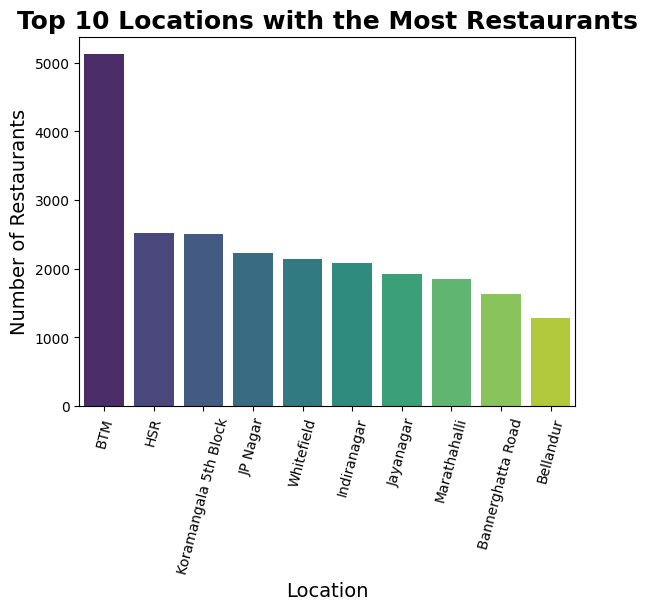

In [160]:
top_locations=df["location"].value_counts().head(10)
sns.barplot(x=top_locations.index,y=top_locations.values,palette="viridis")
plt.xlabel("Location",fontsize=14)
plt.ylabel("Number of Restaurants",fontsize=14)
plt.title("Top 10 Locations with the Most Restaurants",fontsize=18,fontweight='bold')
plt.xticks(rotation=75)
plt.show()

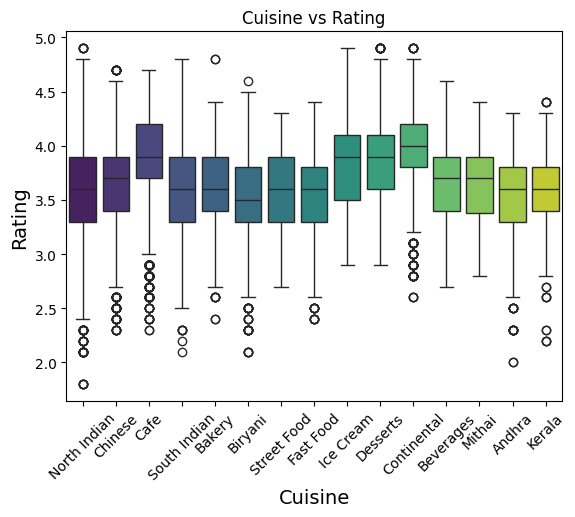

In [161]:
df['primary_cuisine'] = df['cuisines'].astype(str).str.split(",").str[0]
top_15 = df['primary_cuisine'].value_counts().head(15).index
df_top = df[df['primary_cuisine'].isin(top_15)]
sns.boxplot(x='primary_cuisine', y='rate', data=df_top,palette="viridis")
plt.xlabel("Cuisine",fontsize=14)
plt.ylabel("Rating",fontsize=14)
plt.xticks(rotation=45)
plt.title("Cuisine vs Rating")
plt.show()

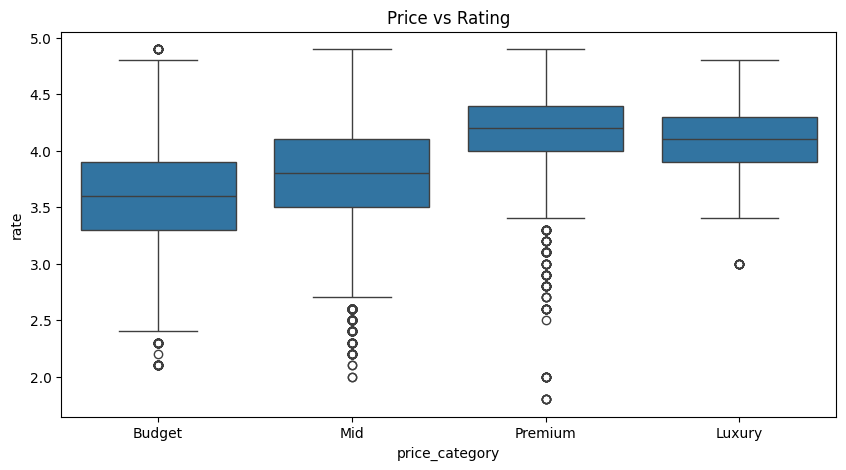

In [162]:
df['price_category'] = pd.cut(df['approx_cost(for two people)'],
                              bins=[0, 500, 1000, 2000, 10000],
                              labels=['Budget', 'Mid', 'Premium', 'Luxury'])
plt.figure(figsize=(10, 5))
sns.boxplot(x='price_category', y='rate', data=df)
plt.title("Price vs Rating")
plt.show()

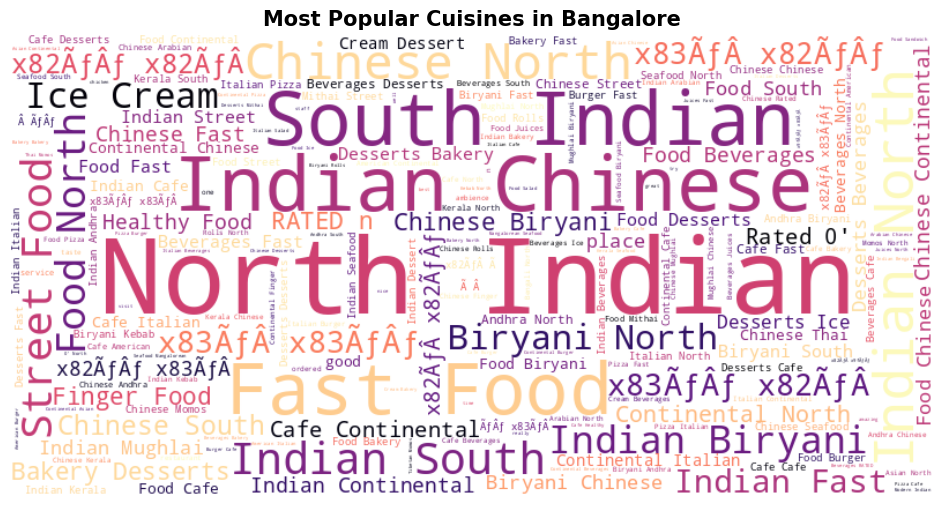

In [163]:
text = " ".join(df['cuisines'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Popular Cuisines in Bangalore", fontsize=15, fontweight='bold')
plt.show()

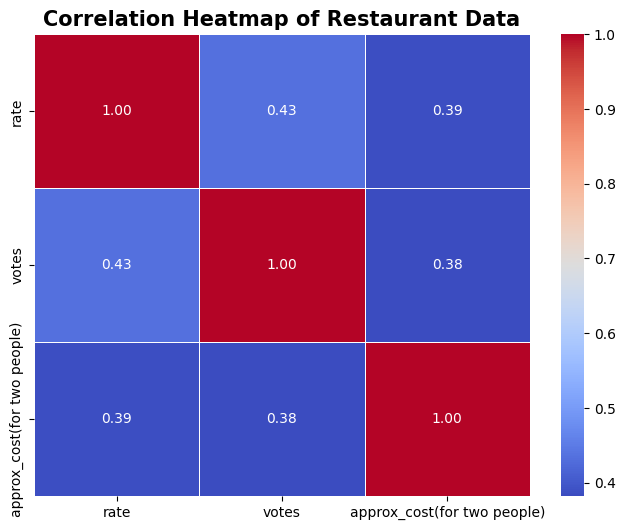

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = df[['rate', 'votes', 'approx_cost(for two people)']]
corr_matrix = num_cols.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Restaurant Data", fontsize=15, fontweight='bold')
plt.show()